In [1]:
import os
import jax
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# from optim_funcs import sgd, adam

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

In [22]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, "outputs/WR137/")

load_dict = lambda x: np.load(x, allow_pickle=True).item()
cal_vis_outputs = load_dict(os.path.join(output_path, "stare_latest_cal_vis.npy"))

print(cal_vis_outputs.keys())

dict_keys(['F480M'])


In [23]:
for key, d in cal_vis_outputs["F480M"].items():
    print(key, d.shape)

u (1300,)
v (1300,)
vis_mat (420, 1300)
phi_mat (420, 1300)
K_vis_mat (349, 420)
K_phi_mat (349, 420)
parang ()
wavel ()
O_vis (349,)
O_phi (349,)
O_vis_cov (349, 349)
O_phi_cov (349, 349)
O_vis_mat (349, 349)
O_phi_mat (349, 349)
O_vis_eigv (349,)
O_phi_eigv (349,)
disco_vis_mat (349, 1300)
disco_phi_mat (349, 1300)
K_vis (349,)
K_vis_cov (349, 349)
K_phi (349,)
K_phi_cov (349, 349)
vis (420,)
vis_cov (420, 420)
phi (420,)
phi_cov (420, 420)


In [3]:
from dorito.model_fits import OIFit
from dLux import utils as dlu
from amigo.misc import interp


class ResolvedOIFit(OIFit):
    """
    Extending the OIFit class to include methods for handling resolved source fits.
    """

    def initialise_params(self, model, distribution):
        """
        Initialise the parameters for the resolved OI fit.
        This method sets up the log distribution and base UV parameters.
        The log distribution is the logarithm of the resolved source distribution,
        normalised to sum to 1. The base UV is the Fourier transform of a delta function
        at the centre of the distribution, which is used for normalisation.

        Args:
            model: The model object containing the parameters.
            distribution: The distribution of the resolved source.

        Returns:
            params: A dictionary containing the initialised parameters for the model fit.
        """

        params = {}  # Initialise an empty dictionary for parameters
        distribution /= distribution.sum()  # normalise the distribution

        params["log_dist"] = self.get_key("log_dist"), np.log10(distribution)
        params["base_uv"] = self.get_key("base_uv"), self.get_base_uv(
            model, distribution.shape[0]
        )

        return params

    def get_key(self, param):

        match param:
            case "log_dist":
                return self.filter
            case "base_uv":
                return self.filter  # this is probably unnecessary

    def map_param(self, param):
        """
        The `key` argument will return only the _key_ extension of the parameter path,
        which is required for object initialisation.
        """

        # Map the appropriate parameter to the correct key
        if param in ["log_dist", "base_uv"]:
            return f"{param}.{self.get_key(param)}"

        # Else its global
        return param

    def get_base_uv(self, model, n_pix):
        """
        Get the base uv for normalisation

        Args:
            model: The model object containing the parameters.
            n_pix: The number of pixels in one axis of the distribution.
        Returns:
            Array: The base UV for normalisation, which is the Fourier transform of a delta function.
        """
        ind = n_pix // 2
        base_dist = np.zeros((n_pix, n_pix)).at[ind, ind].set(1.0)

        # base uv for normalisation
        base_uv = self.to_otf(model, base_dist)
        return base_uv

    def to_otf(self, model, distribution):
        """
        Transform the distribution to the OTF plane (Optical Transfer Function).
        This method performs a Matrix Fourier Transform of the distribution and returns the
        resulting visibilities in the OTF format.
        Args:
            model: The model object containing the parameters.
            distribution: The distribution of the resolved source.
        Returns:
            dlu.MFT: The OTF visibilities as a dLux MFT object.
        """

        return dlu.MFT(
            phasor=distribution + 0j,
            wavelength=self.wavel,
            pixel_scale_in=model.pscale_in,
            npixels_out=model.uv_npixels,
            pixel_scale_out=model.uv_pscale,
        )

    def to_cvis(self, model, distribution):

        # Perform MFT and move to OTF plane
        uv = self.to_otf(model, distribution)  # shape (102, 102)

        # Normalise the complex u,v plane
        uv /= model.params["base_uv"][self.get_key("base_uv")]

        # Downsample to the desired u,v resolution
        uv = dlu.downsample(uv, 2, mean=True)  # shape (51, 51)

        # flatten and take first half (u,v symmetry)
        cvis = uv.flatten()[: uv.size // 2]

        return cvis

    def model_disco(self, model, distribution):
        """
        Compute the model visibilities and phases for the given model object.
        """
        cvis = self.to_cvis(model, distribution)
        return self.flatten_model(cvis)

    def rotate(self, distribution, clip=True):
        """
        Rotate the distribution by the parallactic angle.
        This method rotates the distribution using the dLux utility functions.
        Args:
            distribution: The distribution of the resolved source.
            clip: If True, clips the distribution to enforce positivity.
        Returns:
            Array: The rotated distribution, optionally clipped to enforce positivity.
        """
        knots = dlu.pixel_coords(distribution.shape[0], 1.0)
        samps = dlu.rotate_coords(knots, dlu.deg2rad(self.parang))

        distribution = interp(
            distribution,
            knots,
            samps,
            method="cubic",
        )

        # clipping to enforce positivity
        if clip:
            return np.clip(distribution, min=0.0, max=None)

        return distribution

    def dirty_image(self, model, npix=None, rotate=True):
        """
        Get the dirty image via MFT. This is the image that would be obtained
        if the visibilities were directly transformed back to the image plane.

        Args:
            model: The model object containing the parameters.
            npix: The number of pixels in one axis of the dirty image.
                    If None, uses the same size as the model source distribution.
            rotate: If True, rotates the dirty image by the parallactic angle.
                    If a float, rotates by that (-'ve) angle in radians.
        Returns:
            Array: The dirty image, normalised to sum to 1.
        """

        if npix is None:
            npix = model.get_distribution(self).shape[0]

        # converting to u,v visibilities
        log_vis = np.dot(np.linalg.pinv(self.vis_mat), self.vis)
        phase = np.dot(np.linalg.pinv(self.phi_mat), self.phi)
        vis_im, phase_im = vis_to_im(log_vis, phase, (51, 51))

        # exponentiating
        uv = np.exp(vis_im + 1j * phase_im)

        # Getting the dirty image
        dirty_image = dlu.MFT(
            phasor=uv,
            wavelength=self.wavel,
            pixel_scale_in=2 * model.uv_pscale,
            npixels_out=npix,
            pixel_scale_out=model.pscale_in,
            inverse=True,
        )

        # Taking amplitudes
        dirty_image = np.abs(dirty_image)

        # Optional rotation of the dirty image
        if rotate:
            dirty_image = self.rotate(dirty_image)

        # Normalise the image
        return dirty_image / dirty_image.sum()

    def __call__(self, model, rotate=False):
        """
        Simulate the DISCOs from the resolved source distribution.
        This method retrieves the distribution from the model, optionally rotates it,
        and then computes the DISCOs using the model_disco method.
        Args:
            model: The model object containing the parameters.
            rotate: If True, rotates the distribution by the parallactic angle.
                    If a float, rotates by that (-'ve) angle in radians.
        Returns:
            tuple: A tuple containing the amplitudes and phases in the DISCO basis.
        """
        # NOTE: Distribution must be odd number of pixels in one axis
        distribution = model.get_distribution(self)

        if rotate:
            distribution = self.rotate(distribution)

        return self.model_disco(model, distribution=distribution)

In [4]:
optics_diameter = 6.603464  # JWST aperture diameter in meters
otf_coords = dlu.pixel_coords(51, 2 * optics_diameter)

ois = [
    ResolvedOIFit(oi_data, key, filter=key[:5])
    for key, oi_data in cal_vis_outputs.items()
]

distribution = np.ones((102, 102))

model = dorito.models.ResolvedDiscoModel(
    ois,
    distribution,
    uv_npixels=2 * otf_coords.shape[-1],
    uv_pscale=0.5 * np.diff(otf_coords[0, 0]).mean(),
    oversample=6.0,
)

In [5]:
def normalise_distribution(model_params, args):
    params = model_params.params

    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            distribution = 10**log_dist

            # centre = distribution.shape[0] // 2
            # norm = distribution[centre, centre]

            norm = distribution.sum()

            params["log_dist"][k] = np.log10(distribution / norm)

    return model_params.set("params", params), args


def looper(looper, loss_dict):
    loss = np.array([v[-1] for v in loss_dict.values()]).mean(0)
    looper.set_description(f"Loss: {loss:.6e}")


def log_likelihood(model, oi, args={}):
    data = np.concatenate([oi.vis, oi.phi])
    err = np.concatenate([oi.d_vis, oi.d_phi])
    model_vis = oi(model)  # same shape as data

    residual = data - model_vis
    nll = np.sum(0.5 * (residual / err) ** 2 + np.log(err * np.sqrt(2 * np.pi)))

    return nll


def phase_centre(model, oi, args={}):

    distribution = model.get_distribution(oi)

    # Tip/Tilt vectors (ramp in u,v)
    mu = oi.u / np.linalg.norm(oi.u)
    mv = oi.v / np.linalg.norm(oi.v)

    # to log visibilities
    cvis = oi.to_cvis(model, distribution)
    phase = np.angle(cvis)

    # calculating the phase centre of the distribution
    return np.hypot(np.dot(mu, phase), np.dot(mv, phase))


def loss_fn(model, exposure, args={}):
    loss = log_likelihood(model, exposure, args)

    # centre = phase_centre(model, exposure, args)
    # loss += -jax.scipy.stats.norm.logpdf(centre, loc=0.0, scale=1e-3)

    return loss, ()

In [6]:
@zdx.filter_grad("log_dist")
def loss(model, exposure, args):
    return loss_fn(model, exposure, args)[0]


grads = loss(model, ois[0], {"reg_func_dict": {}, "reg_dict": {}})

/home/max/miniforge3/envs/v10/lib/python3.13/site-packages/jax/_src/numpy/lax_numpy.py:5555: ComplexWarning: Casting complex values to real discards the imaginary part
  out_array: Array = lax_internal._convert_element_type(


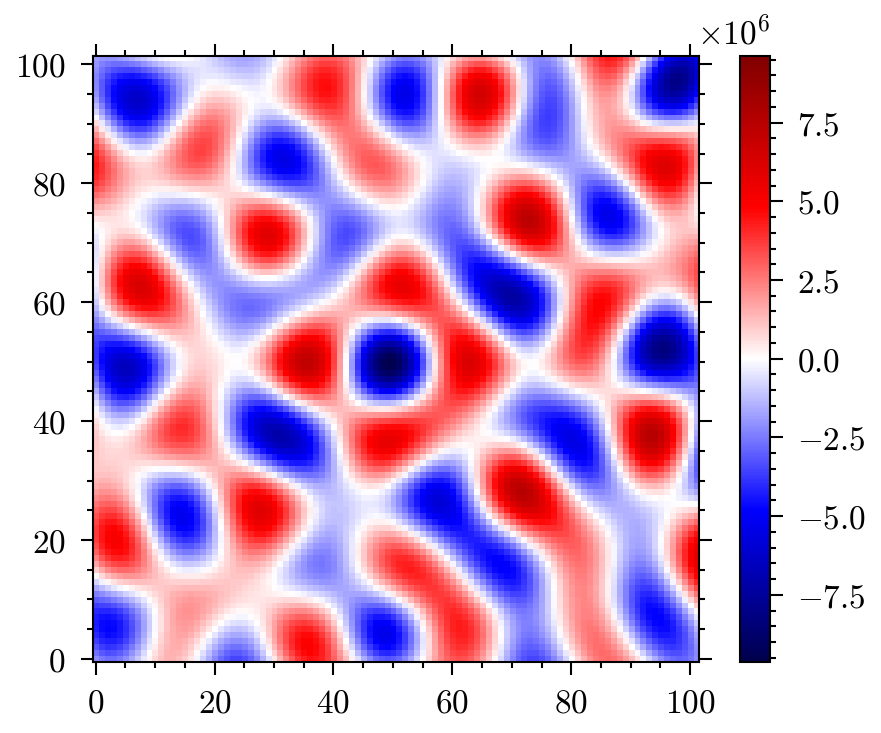

In [7]:
grad = grads.params["log_dist"]["F480M"]

plt.imshow(grad, cmap=seismic, norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.show()

In [8]:
jax.config.update("jax_debug_nans", True)

n_epoch = 8_000

config = {
    # "log_dist": adam(1e-1, 0, (3000, 5)),
    # "log_dist": adam(1e-3, 0),
    # "log_dist": adam(2e-2, 0, (100, 0.1), (2000, 0.1)),
    "log_dist": adam(1e-2, 0, (5000, 0.5)),
    # "log_dist": sgd(1e-8, 0, (1000, 0.1)),
    # "log_dist": sgd(1e-3, 0),
    # "log_dist": optax.sgd(1e-8, 0),
    # "log_dist": sgd(1e-8, 0)  # (100, 10), (2000, 0.5)),
    # "log_dist": sgd(5e-9, 0, (500, 2), (1000, 2)),
    # "log_dist": sgd(1e-8, 0, (10, 5), (500, 0.25), (1000, 1.5), (1300, 0.75)),
}

args = {
    "reg_func_dict": {
        "ME": dorito.stats.ME,
        "TV": dorito.stats.TV,
        "L2": dorito.stats.L2,
        "TSV": dorito.stats.TSV,
    },
    "reg_dict": {
        # "ME": 1e5,
        # "ME": 1e5,
        # "TV": 1.0,
        # "L2": 1e-5,
        # "TSV": 5e6,
    },
}

trainer = amigo.fitting.Trainer(
    # trainer = Trainer(
    # loss_fn=regularised_loss_fn,
    loss_fn=loss_fn,
    # cache=fisher_cache,
    # grad_fn=grad_fn,
    norm_fn=normalise_distribution,
    looper_fn=looper,
)

trainer = trainer.update_fishers(
    model=model,
    exposures=[],
    parameters=[],
)

# Train the model
result = trainer.train(
    # model=bfgs_model,
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=ois,
    args=args,
    # batches=exposures,
)

0it [00:00, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 780,717,472.68
Estimated run time: 0:00:52
Full Time: 0:01:40
Final Loss: 116,967.01


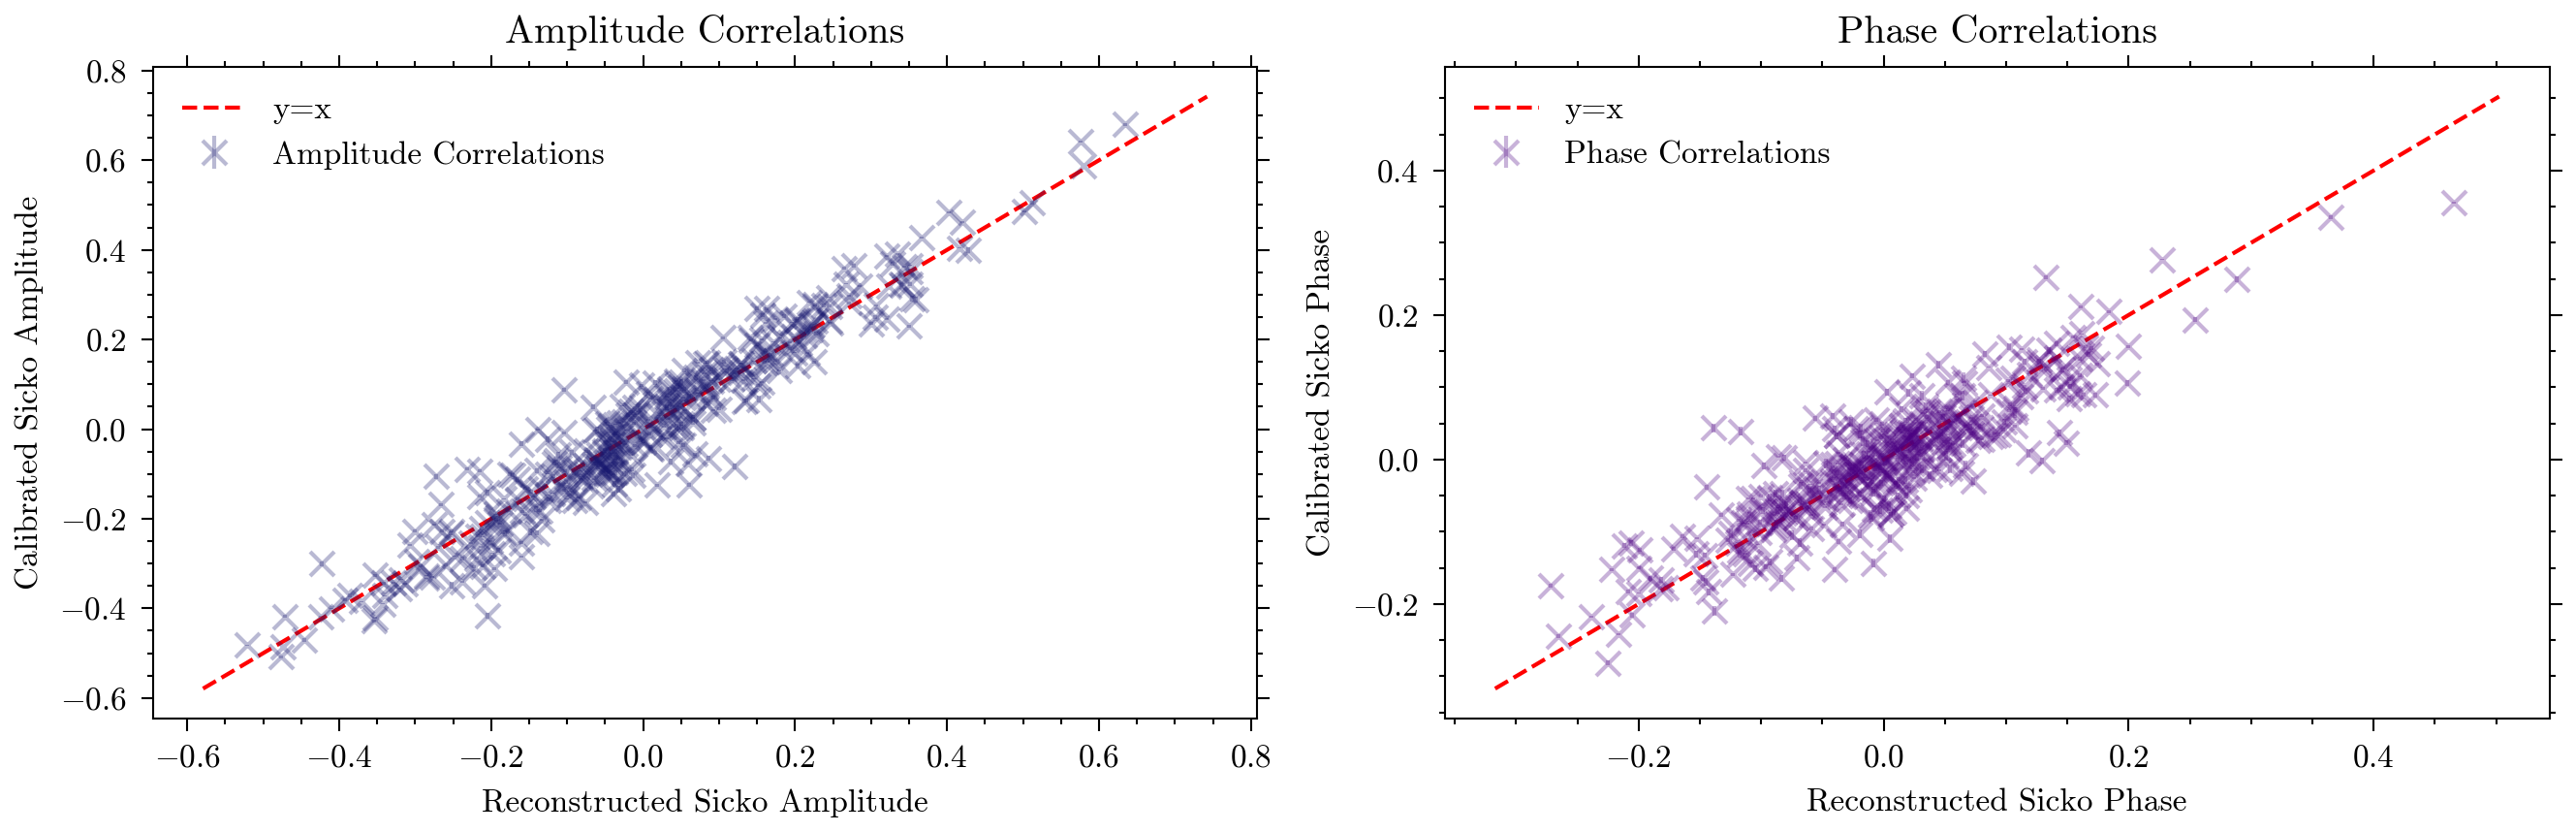

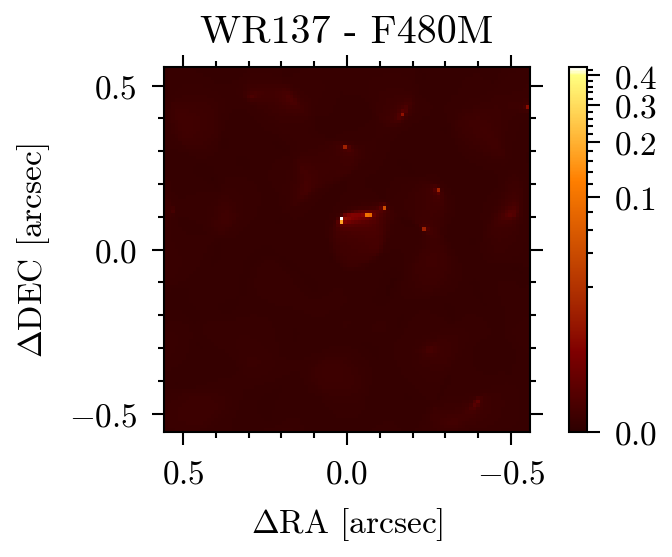

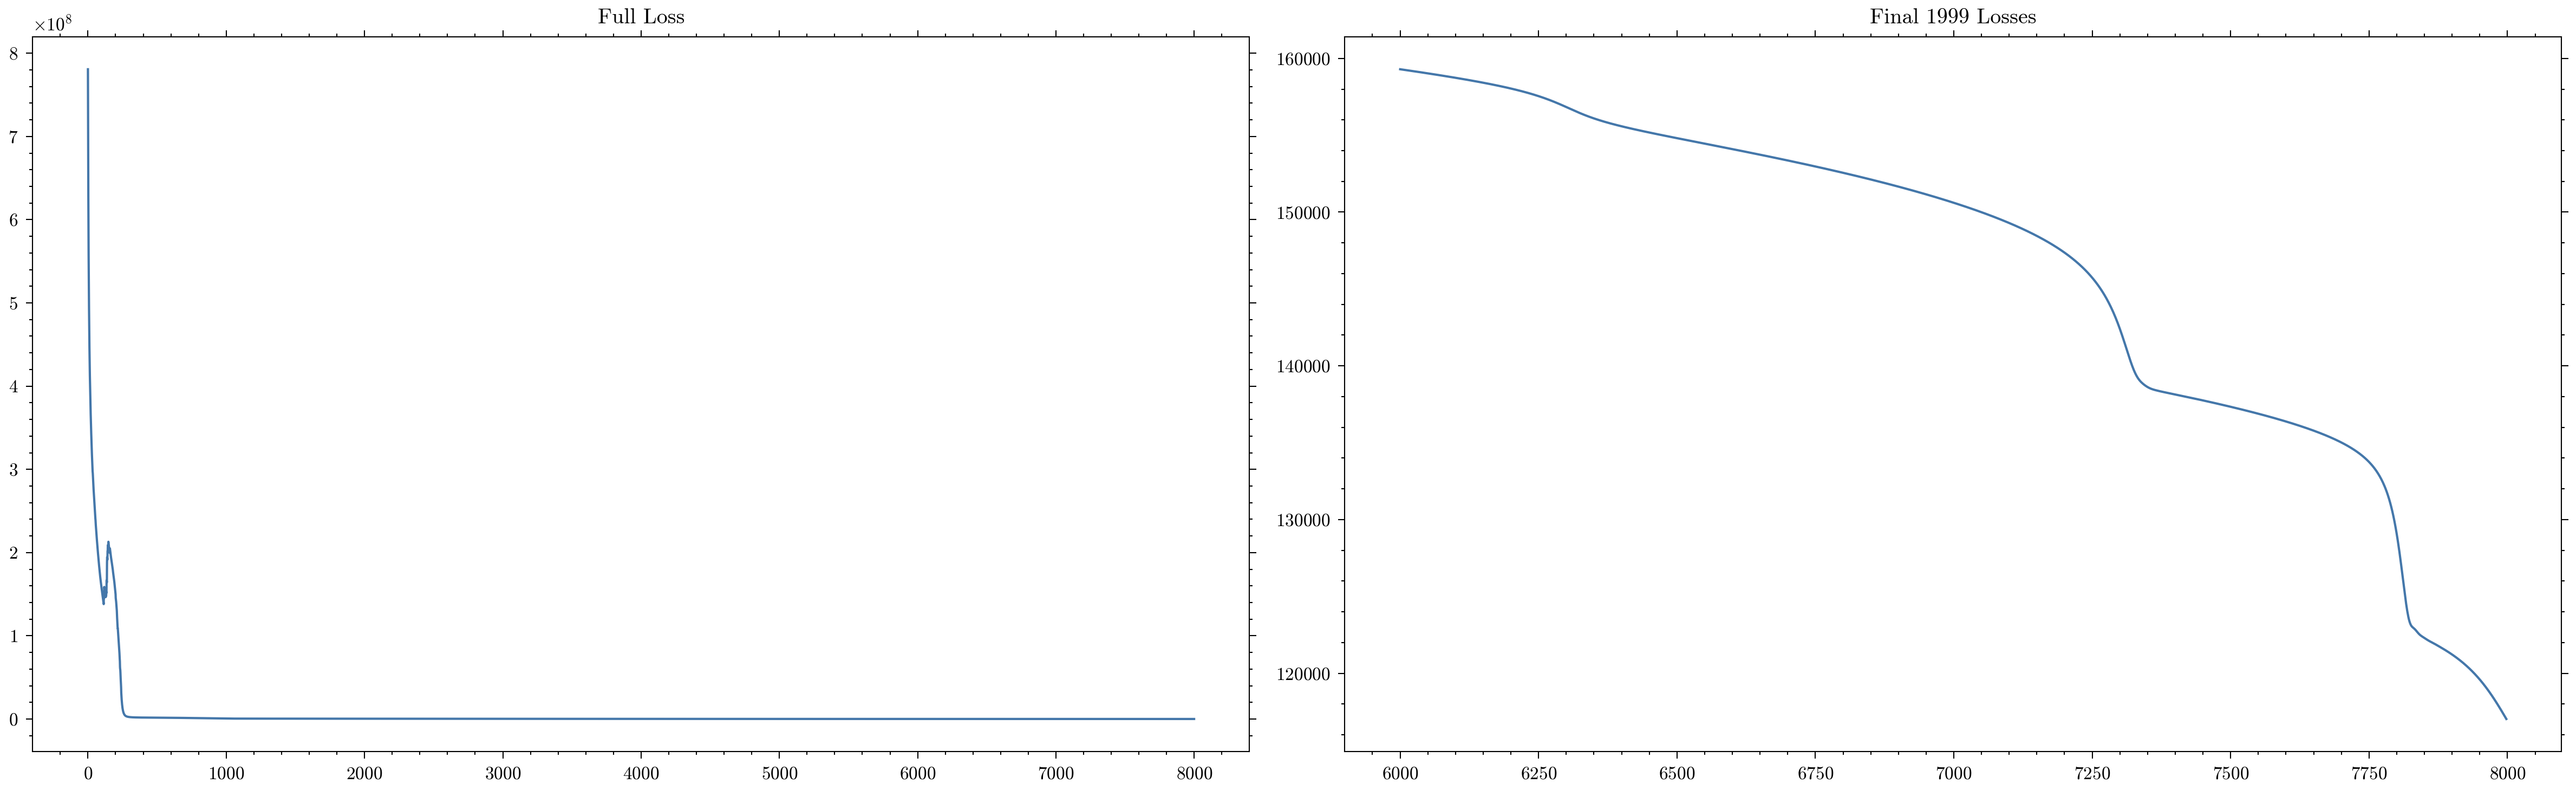

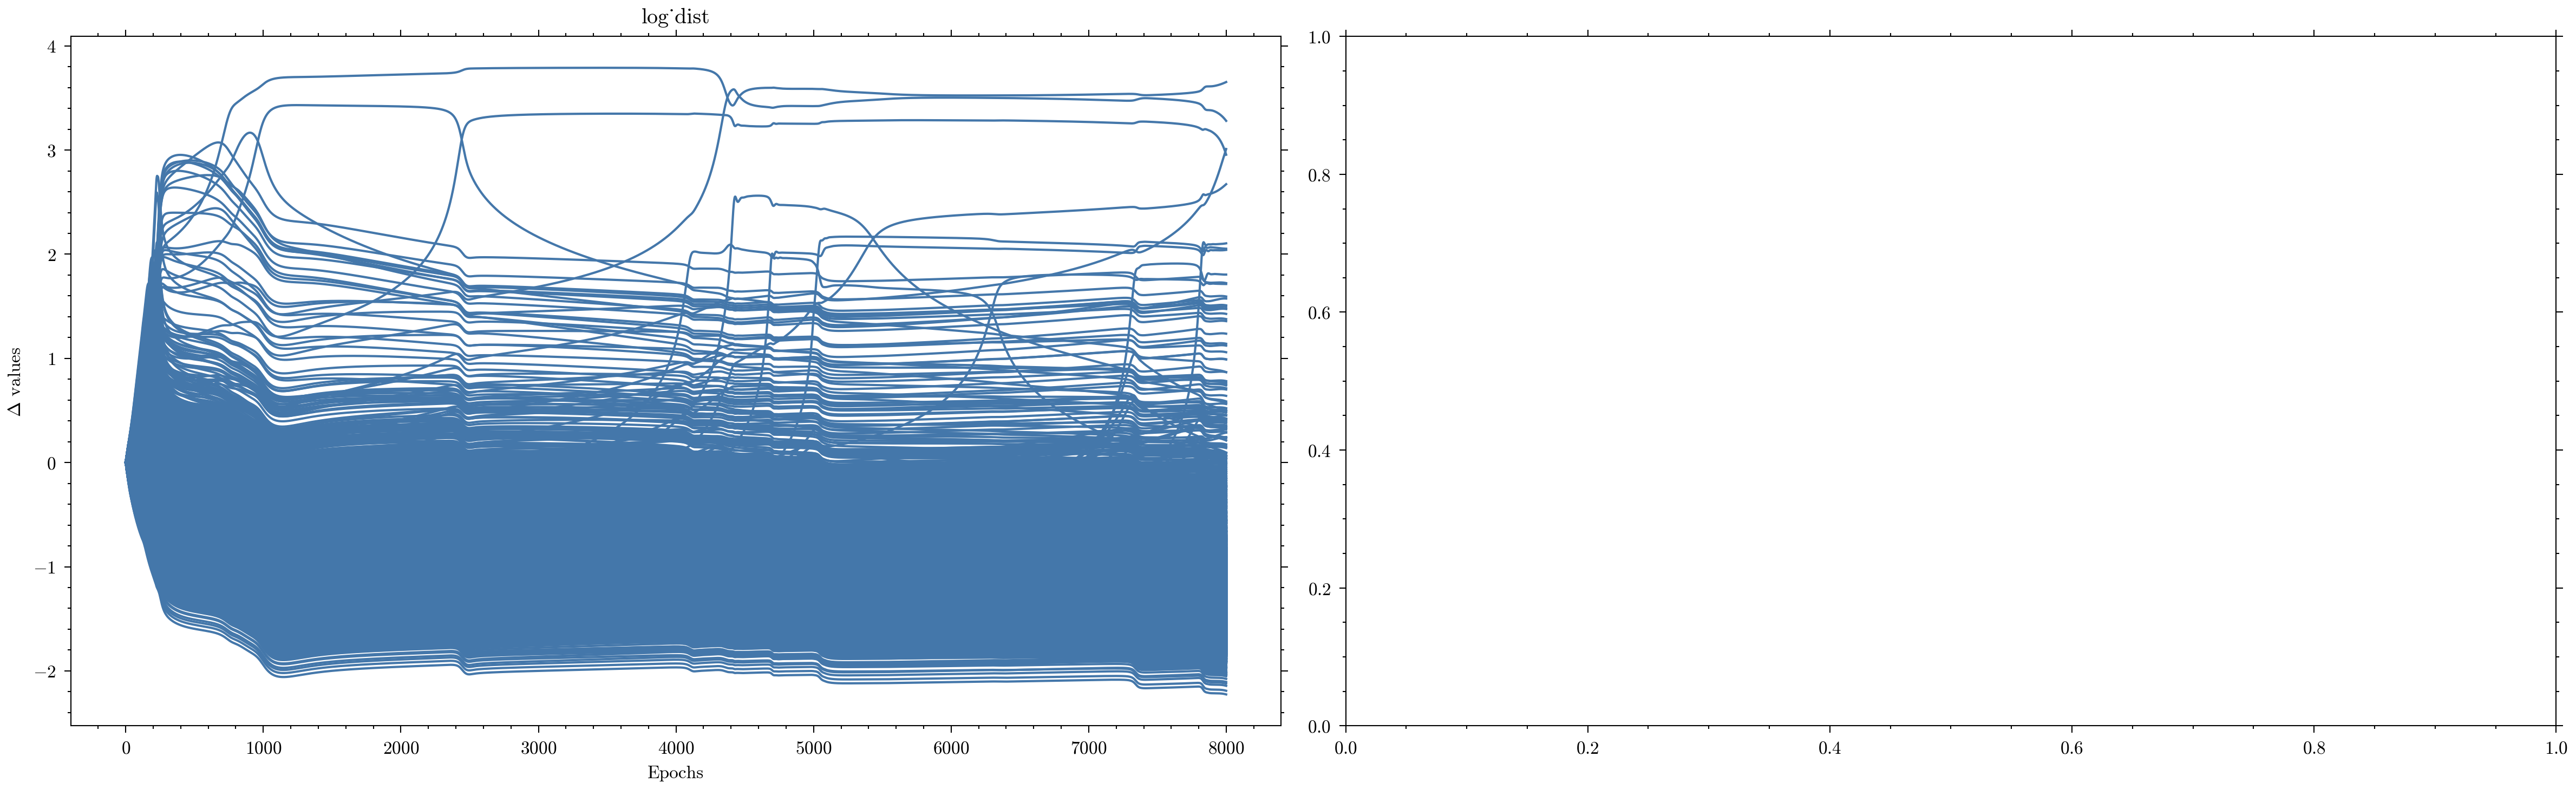

In [9]:
from amigo import plotting

for oi in ois:
    dist = 10 ** result.model.params["log_dist"][oi.get_key("log_dist")]

    disco_amp, disco_phase = np.split(oi(result.model), 2)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        disco_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.3,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Reconstructed Sicko Amplitude")
    ax[0].set_ylabel("Calibrated Sicko Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        disco_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.3,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Reconstructed Sicko Phase")
    ax[1].set_ylabel("Calibrated Sicko Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(3, 2))

    c0 = dorito.plotting.plot_result(
        ax,
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_10u",
        power=0.3,
        vmin=0,
    )

    fig.colorbar(c0)
    ax.set_title(f"WR137 - {oi.key}")
    plt.tight_layout()
    plt.show()

plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
plotting.plot(result.history)